In [4]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [5]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from plot_params import *
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Run scan_L_A.py to generate the results for Fig2.ipynb


In [6]:
def schatten_2_over_L(A, L):
    p = 2.0 / L
    
    # Compute singular values
    s = np.linalg.svd(A, compute_uv=False)
    
    # Compute Schatten-p norm
    return np.sum(s**p)**(1.0/p)

In [11]:

df_sweep_s_a = pd.read_csv('./sweep_S_A_seed_circular_df.csv')  
df_sweep_s_a

,L,A,NC1,PR,order,S
0,NaN,12,-2.851350,1.131349,0.989651,28.0
1,NaN,7,-2.403103,1.191102,0.985179,26.0
2,NaN,2,-1.309230,2.147473,0.541947,20.0
3,NaN,1,-1.498768,2.261436,0.497157,20.0
4,NaN,1,-1.541506,3.074180,0.116395,26.0
...,...,...,...,...,...,...
495,NaN,11,-2.636480,1.113227,0.985061,26.0
496,NaN,9,-2.381733,1.152981,0.988580,28.0
497,NaN,1,-1.382805,2.055431,0.815121,20.0
498,NaN,1,-1.731833,2.431854,0.199175,24.0


In [12]:

import pickle as pkl

df_sweep_s_a = pd.read_csv('sweep_S_A_seed_circular_df.csv')  

metrics = ['order', 'PR']
S_values = df_sweep_s_a['S'].sort_values().unique() # np.arange(20, 50)
A_col = 'A'
S_col = 'S'
metric = 'PR'
thresh_arr = np.zeros((len(S_values), 100))
means_l = []
A_sorted_l = []
for i, S_val in tqdm(enumerate(S_values)):
    # Select rows with S == S_val
    df_S = df_sweep_s_a[df_sweep_s_a[S_col] == S_val]
    # Drop NaN in A or metric
    df_S = df_S[[A_col, metric]].dropna()
    # Sort A for consistent x-axis
    A_sorted = sorted(df_S[A_col].unique())
    for j in range(100):
        vals = []
        for a in A_sorted:
            val = np.random.choice(df_S[df_S[A_col] == a][metric].values)
            vals.append(val)
        vals = np.array(vals)
        if metric == 'PR':
            thresh_arr[i, j] = (np.where(vals<2)[0][0]+1)/S_val
        elif metric == 'order':
            thresh_arr[i, j] = (np.where(vals>0.95)[0][0]+1)/S_val
    means = []
    stds = []
    for a in A_sorted:
        vals = df_S[df_S[A_col] == a][metric].values
        means.append(np.median(vals) if len(vals) > 0 else np.nan)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    cmap = plt.get_cmap('plasma')
    norm = mcolors.Normalize(vmin=S_values.min(), vmax=S_values.max()+5)
    color = cmap(norm(S_val))
    A_sorted_l.append(A_sorted)
    means_l.append(means)

5it [00:00,  5.13it/s]


In [13]:
def panel_label(ax, label):
    ax.text(
        -0.2, 1.2, label,
        transform=ax.transAxes,      # use axes coordinates
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='left'
    )

5it [00:00, 2716.52it/s]
/tmp/ipykernel_1999112/1158914902.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


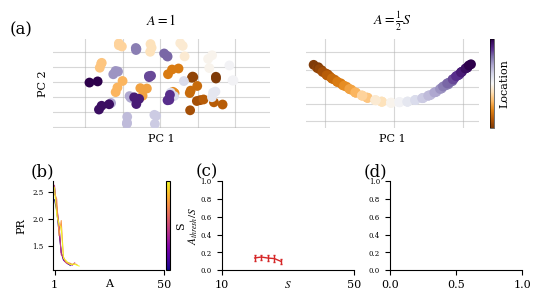

In [24]:
# Use the global matplotlib styling set above
fig = plt.figure(figsize=(1.1*FIG_WIDTH, 3))
gs = GridSpec(2, 6, height_ratios=[1, 1], hspace=0.6, wspace=0.75)

# --- First row: 2D PCA plots for two datasets ---

# Load the two specific files
file1 = '../results/sweep_S_A_seed_circular/data_max_move_1_length_corridors_[np.int64(28)]_seed_1.pkl'
file2 = '../results/sweep_S_A_seed_circular/data_max_move_12_length_corridors_[np.int64(28)]_seed_1.pkl'

with open(file1, 'rb') as f:
    data_dict1 = pkl.load(f)

with open(file2, 'rb') as f:
    data_dict2 = pkl.load(f)

ax_pca1 = fig.add_subplot(gs[0, 0:3])
plot_pca_subplot(ax_pca1, data_dict1, r'$A=1$')

ax_pca2 = fig.add_subplot(gs[0, 3:6])
plot_pca_subplot(ax_pca2, data_dict2, r'$A=\frac{1}{2}S$', cb=True, y_label=False)


# --- Second row: original 3 heatmaps ---

axs = [fig.add_subplot(gs[1, i*2:i*2+2]) for i in range(3)]

### 2 left plots
for i, S_val in tqdm(enumerate(S_values)):
    color = cmap(norm(S_val))
    axs[0].plot(A_sorted_l[i], means_l[i], color=color, label=f"S={S_val}", lw=0.7)
axs[0].set_xlabel("A")
axs[0].set_ylabel(metric)
axs[0].set_xticks([1, 50])
axs[0].xaxis.set_label_coords(0.5, -0.1)

# Add colorbar after the loop
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=min(S_values), vmax=max(S_values))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs[0], pad=0.01)
cbar.set_label('S')
cbar.ax.set_yticklabels([])  # Remove colorbar ticks
cbar.ax.set_yticks([])
# Convert thresh_l_l to array for easier manipulation
means = np.mean(thresh_arr, axis=1)
sems = np.std(thresh_arr, axis=1)
axs[1].errorbar(S_values, means, yerr=sems, lw=1, c='tab:red', fmt='-o', capsize=0.5, markersize=0)
axs[1].set_xlabel(r'$S$')
axs[1].set_ylabel(r'$A_{thresh}/S$', labelpad=0.1)
axs[1].set_ylim(0, 1)
axs[1].set_xticks([10, 50])
axs[1].xaxis.set_label_coords(0.5, -0.1)

panel_label(ax_pca1, '(a)')
panel_label(axs[0], '(b)')
panel_label(axs[1], '(c)')
panel_label(axs[2], '(d)')
plt.tight_layout()
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig2.png', dpi=300, bbox_inches='tight')
plt.show()


10it [00:00, 1954.29it/s]


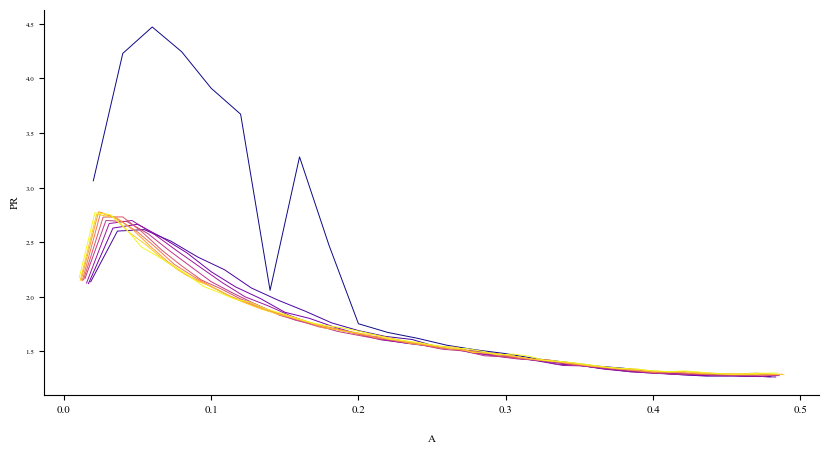

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs = [axs]
### 2 left plots
for i, S_val in tqdm(enumerate(S_values)):
    color = cmap(norm(S_val))
    axs[0].plot(A_sorted_l[i]/S_val, means_l[i], color=color, label=f"S={S_val}", lw=0.7)
axs[0].set_xlabel("A")
axs[0].set_ylabel(metric)
# axs[0].set_xticks([1, 50])
axs[0].xaxis.set_label_coords(0.5, -0.1)

0it [00:00, ?it/s]

50it [00:00, 2046.82it/s]


(0.0, 1.0)

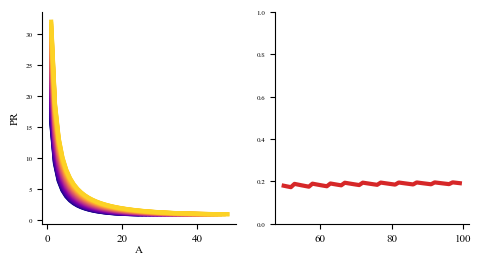

In [ ]:
def calc_PR_theory(S,A):
    M = 2*A+1
    return S**3 / (M*(S**2+S*M-M**2))

S_values = np.arange(50, 100)
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=S_values.min(), vmax=S_values.max()+5)

fig, axs = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_WIDTH/2))
thresh_l = []
thresh = 2
### 2 left plots
for i, S_val in tqdm(enumerate(S_values)):
    A_l = np.arange(1, S_val//2)
    color = cmap(norm(S_val))
    PR_l = calc_PR_theory(S_val,A_l)
    thresh_l.append(np.where(PR_l<thresh)[0][0]/S_val)
    axs[0].plot(A_l, PR_l, color=color, label=f"S={S_val}", lw=3)
axs[0].set_xlabel("A")
axs[0].set_ylabel(metric)
# axs[0].set_xticks([1, 50])
axs[0].xaxis.set_label_coords(0.5, -0.1)
axs[1].plot(S_values, thresh_l, color='tab:red', label=f"S={S_val}", lw=3)
axs[1].set_ylim(0, 1)